# Preamble

##Imports
Include (import) packages first:

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import f1_score
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# from sklearn.metrics import plot_confusion_matrix
from sklearn.model_selection import cross_val_score
from scipy import stats
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
# for exporting to STM32, convert to ONNX
# import onnx
# from skl2onnx import to_onnx
# from skl2onnx import convert_sklearn
# from skl2onnx.common.data_types import FloatTensorType
# for exporting to STM32, convert to tflite
import tensorflow as tf

SEED_VALUE = 42 # Fix seed to make training deterministic.
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

# suppress some print msgs from tf. daming sinasabi
tf.get_logger().setLevel('WARNING')


axis_label_size = 26
tick_label_size = 20
lgnd_label_size = 20

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## General Functions

In [ ]:
def loadFile(fn):
    workingDir = "/content/drive/MyDrive/CoE 199 (2s2425)/AS7343 Calibration/abs_per_ch/"
    csvPath = workingDir + fn
    return pd.read_csv(csvPath)

def createData(df_raw):
    # y is 2nd column, x is 3rd column
    x, y = df_raw.iloc[:,2].to_numpy().reshape(-1, 1), np.array([df_raw.iloc[:,1]]).reshape(-1,1)

    # 80:20 train-test split, randomized
    # X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=15)

    X_train = np.array([[]]).reshape(-1,1)
    X_test = np.array([[]]).reshape(-1,1)
    y_train = np.array([[]]).reshape(-1,1)
    y_test = np.array([[]]).reshape(-1,1)

    # print(f'X_train shape: {X_train.shape}')
    # print(f'x_all shape: {x.shape}')
    # print(f'Y_train shape: {y_train.shape}')
    # print(f'y_all shape: {y.shape}')

    # 66:33 train-test split, light + dark shades train, med test
    for i in range(0,5): # all colors
        start, end = (i*18)+6, (i*18)+12
        X_test = np.concatenate((X_test, x[start:end,:]))
        y_test = np.concatenate((y_test, y[start:end,:]))

        start, end = (i*18), (i*18)+6
        X_train = np.concatenate((X_train, x[start:end,:]))
        y_train = np.concatenate((y_train, y[start:end,:]))

        start, end = (i*18)+12, (i*18)+18
        X_train = np.concatenate((X_train, x[start:end,:]))
        y_train = np.concatenate((y_train, y[start:end,:]))


    # store data on dict for easier access
    data = {
        'X_all':    x,
        'y_all':    y,
        'X_train':  X_train,
        'y_train':  y_train,
        'X_test':   X_test,
        'y_test':   y_test,
    }
    return data

def calcBaseline(df, plotResults=True):
    x_raw = np.array(df['AS7343']).reshape((-1, 1))
    y_raw = np.array(df['MSI_ref']).reshape((-1, 1))

    sr2 = round(r2_score(x_raw, y_raw), 5)
    smae = round(mae(x_raw, y_raw), 5)
    smse = round(np.sqrt(mse(x_raw, y_raw)), 5)
    slope, intercept, r, p, sterr = stats.linregress(x=x_raw.ravel(), y=y_raw.ravel())
    if (plotResults):
        plotScatter('Baseline', sr2,  smae, smse, x_raw, y_raw)
    else:
        print('stats r2:', round(r**2, 5), ', intercept:', intercept, ', r:', r,  ', p:', p, ', stderr:', sterr)
        print('  metrics r2:', sr2)
        print('  mae:', smae)
        print('  rmse:', smse)
        print('')

    return sr2, smae, smse

def trainModel(model, data, channel, plotResults=True):
    model.fit(data['X_train'], data['y_train'])
    y_pred = model.predict(data['X_test'])

    y_test = data['y_test']
    cn = model.__class__.__name__
    cn += f" {channel}"
    print('Performance Metrics:', cn)
    sr2 = round(r2_score(y_test, y_pred), 5)
    smse = round(np.sqrt(mse(y_test, y_pred)), 5)

    if (plotResults):
        plotScatter(cn, sr2,  smae, smse, data['X_test'], y_test, y_pred)
    else:
        print('  metrics r2:', sr2)
        print('  mae:', smae)
        print('  rmse:', smse)
        print('')

    # return calibrated values for every sensor reading
    return data['X_test'], y_pred, sr2, smse, model

def trainTFModel(model, data, channel, plotResults=True):
  epoch_per_ch = {"450nm": 300, "475nm": 300, "515nm": 300, "550nm": 300,
                  "555nm": 300, "600nm": 300, "640nm": 500, "690nm": 500}
  tf_model = model

  # Define the model consisting of a single neuron.
  tf_model.add(tf.keras.layers.Dense(input_shape=(1,), units=1, bias_initializer='zeros'))

  tf_model.compile(loss='mse')

  # train model
  # 'history' holds loss function
  history = tf_model.fit(data['X_train'], data['y_train'],
                         epochs=epoch_per_ch[channel],
                         validation_data=(data['X_test'], data['y_test']),
                        #  validation_freq=5
                         )
  # make predictions
  y_pred = tf_model.predict(data['X_test'])

  y_test = data['y_test']
  cn = tf_model.__class__.__name__
  cn += f" {channel}"
  print('Performance Metrics:', cn)
  sr2 = round(r2_score(y_test, y_pred), 5)
  smae = round(mae(y_test, y_pred), 5)
  smse = round(np.sqrt(mse(y_test, y_pred)), 5)

  if (plotResults):
      plotScatter(cn, sr2,  smae, smse, data['X_test'], y_test, y_pred)
  else:
      print('  metrics r2:', sr2)
      print('  mae:', smae)
      print('  rmse:', smse)
      print('')

  # return calibrated values for every sensor reading
  return data['X_test'], y_pred, sr2, smae, smse, tf_model, history

## Plot functions

In [ ]:
def plotScatter(title, sr2,  smae, smse, x, y_raw, y_calibrated=None):
    # Format the metrics as text
    tlbl = "Metrics"
    tr2 = f"$R^2$: {sr2}"
    trmse = f"RMSE: {smse}"
    tmae = f"MAE: {smae}"
    # Add the text to the plot
    plt.text(0.05, 0.95, tlbl, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
    plt.text(0.05, 0.88, tr2, transform=plt.gca().transAxes, fontsize=8, verticalalignment='top')
    plt.text(0.05, 0.82, trmse, transform=plt.gca().transAxes, fontsize=8, verticalalignment='top')
    plt.text(0.05, 0.76, tmae, transform=plt.gca().transAxes, fontsize=8, verticalalignment='top')

    plt.scatter(x, y_raw, label="Raw Data")
    if (y_calibrated is not None):
        plt.scatter(x, y_calibrated, label="Calibrated Data")

    plt.legend()
    plt.xlabel("AS7343 readings")
    plt.ylabel("Target Value")
    plt.title(f"{title} Scatter Plot")
    plt.show()

def plotRegression(ch, model, x, y_target):
    step_size = 0.001
    x_input = np.arange(0,x.max()+step_size, step_size)

    # , edgecolor='Red', facecolor='none'
    plt.scatter(x, y_target, label="Actual Data")

    for mdl in model:
      y_pred = mdl.predict(x_input.reshape(-1, 1))
      plt.plot(x_input, y_pred, label=f'{mdl.__class__.__name__}')
    plt.ylabel("Expected Readings")
    plt.xlabel("Obtained Readings")
    plt.title(f"{ch} nm Channel Regression Model/s")
    plt.legend()
    plt.show()


def plotRMSE(rmse_dict):
    ch = [450, 475, 515, 550, 555, 600, 640, 690]
    x_base = list(range(len(ch)))
    barWidth = 0.2

    mdl_idx=0
    for model in rmse_dict.keys():
      if len(rmse_dict[model]) <= 0:
        continue
      x_input = [x+(barWidth*mdl_idx) for x in x_base]
      plt.bar(x_input, rmse_dict[model], label=str(model), width=barWidth)
      mdl_idx+=1
    plt.xticks([x+(barWidth*1.5) for x in x_base], labels=ch)
    plt.yticks(minor=True, ticks=list(np.arange(0,0.6,0.02)))

    # for model in rmse_dict.keys():
    #   plt.plot(ch, rmse_dict[model], label=str(model), marker='o')

    plt.legend()
    plt.xlabel("Channel (in nm)")
    plt.ylabel("RMSE")
    plt.title(f"RMSE of different ML models")
    plt.grid(True, axis='y',which='major')
    plt.show()

def plotR2(r2_scores):
    ch = [450, 475, 515, 550, 555, 600, 640, 690]

    for model in r2_scores.keys():
        plt.plot(ch, r2_scores[model], label=str(model), marker='o')

    plt.legend()
    plt.xlabel("Channel's wavelength (in nm)")
    plt.ylabel("R^2 score")
    plt.title(f"R^2 of different ML models")
    plt.show()

def plot_loss(history):
    plt.figure()
    plt.plot(history.history['loss'], 'g', label='Training Loss')
    plt.plot(history.history['val_loss'], 'b', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# Scatterplot (Raw)

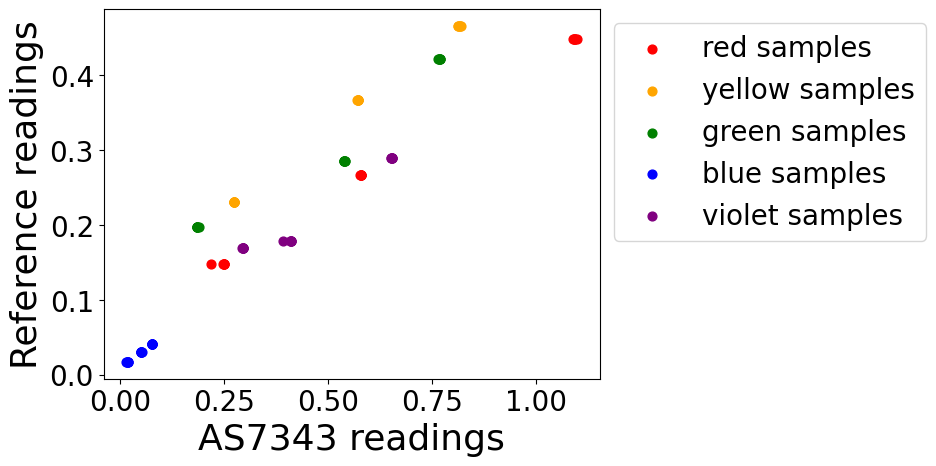

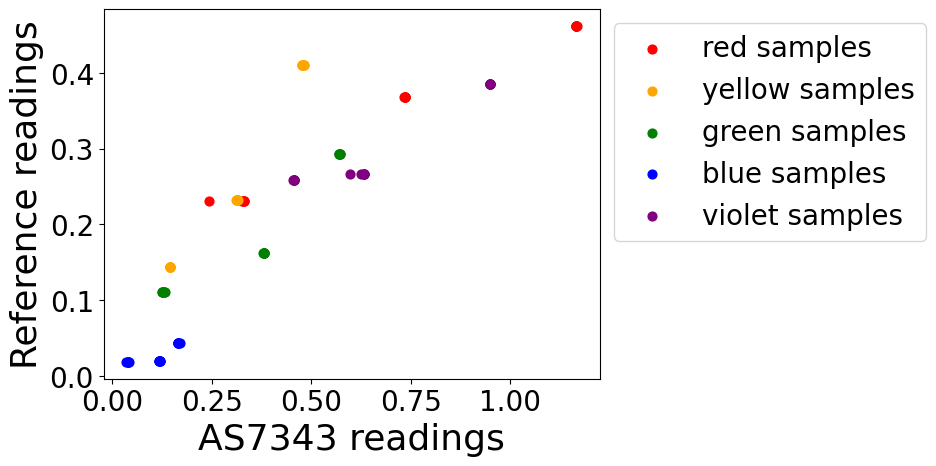

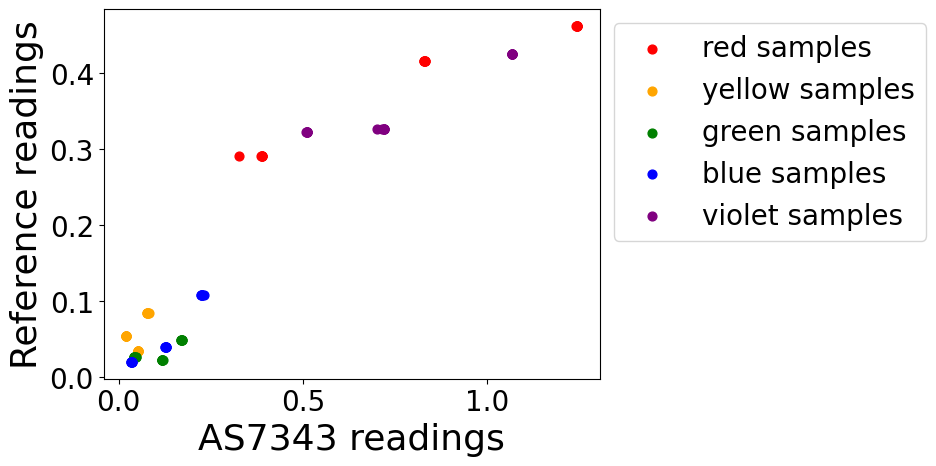

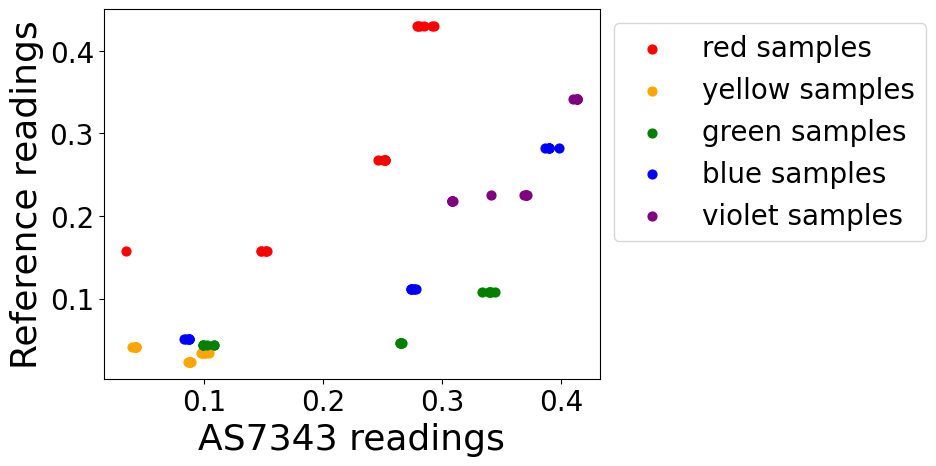

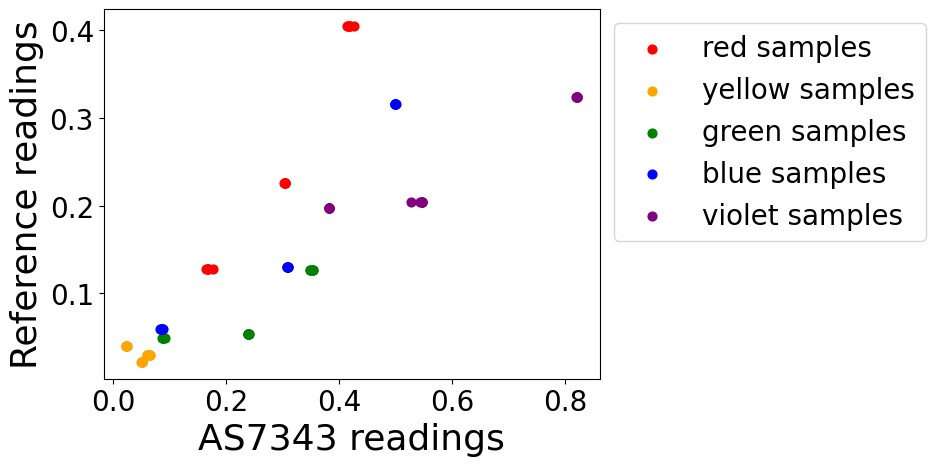

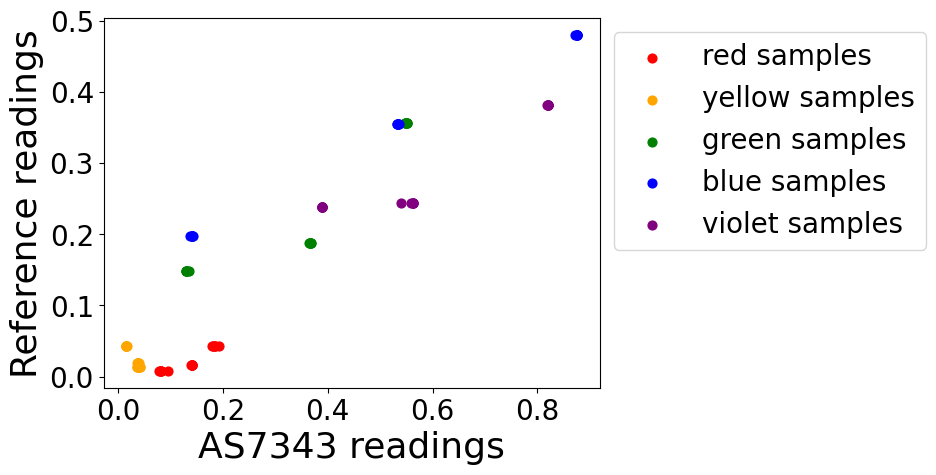

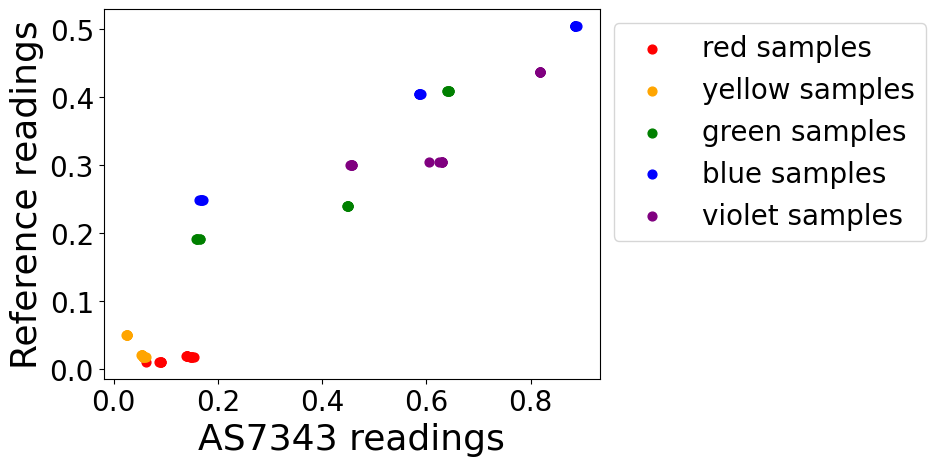

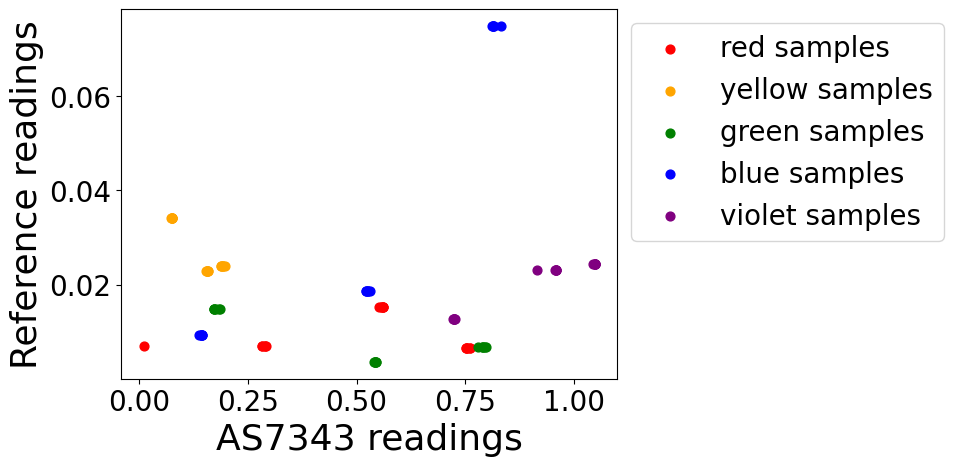

In [ ]:
fp = "/content/drive/MyDrive/CoE 199 (2s2425)/AS7343 Calibration/abs_per_ch/"
ch_str = ['450','475','515','550','555','600','640','690']

for ch in ch_str:
  df = pd.read_csv(fp + f'ch{ch}.csv')

  x,y = df['AS7343'][0:18], df['MSI_ref'][0:18]
  plt.scatter(x,y,label='red samples', color='red', s=40.0)

  x,y = df['AS7343'][18:36], df['MSI_ref'][18:36]
  plt.scatter(x,y,label='yellow samples', color='orange', s=40.0)

  x,y = df['AS7343'][36:54], df['MSI_ref'][36:54]
  plt.scatter(x,y,label='green samples', color='green', s=40.0)

  x,y = df['AS7343'][54:72], df['MSI_ref'][54:72]
  plt.scatter(x,y,label='blue samples', color='blue', s=40.0)

  x,y = df['AS7343'][72:90], df['MSI_ref'][72:90]
  plt.scatter(x,y,label='violet samples', color='purple', s=40.0)

  plt.xlabel('AS7343 readings', fontsize=axis_label_size)
  plt.ylabel('Reference readings', fontsize=axis_label_size)
  plt.tick_params(axis='x', labelsize=tick_label_size)
  plt.tick_params(axis='y', labelsize=tick_label_size)

  plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=lgnd_label_size)
  plt.show()

# Model Training (All ch)


## Initializing Variables

In [ ]:
# list of channels as string
ch = ["450", "475", "515", "550", "555", "600", "640", "690"]

# container for models of each channel
xgb_models = {}
lin_models = {}
tf_models = {}

calib_models = {}

# data extracted per channel
data_per_ch = {}

RMSE_calib = {
    "Baseline": [],
    # "XGB no scaling": [0.02759, 0.05763, 0.04456, 0.03167, 0.01745, 0.06928, 0.01417, 0.00631],
    # "XGBRegressor": [],
    "SKL LinRegr": [],
    "TF LinRegr": []
}

RMSE_comparison = {
    "Prev Enclosure": [0.00034, 0.00693, 0.02829, 0.02745, 0.04521, 0.10493, 0.10821, 0.00814],
    "New Enclosure": []
}

r2_scores = {
    "Baseline": [],
    # "XGB no scaling": [0.95357, 0.78863, 0.93229, 0.93169, 0.97538, 0.75146, 0.992, 0.85155],
    # "XGBRegressor": [],
    "SKL LinRegr": [],
    "TF LinRegr": []
}

history_per_ch = {}

working_dir = "/content/drive/MyDrive/CoE 199 (2s2425)/AS7343 Calibration/abs_per_ch/"

for channel in ch:
  fn = f'ch{channel}.csv'
  df = loadFile(f'ch{channel}.csv')
  data = createData(df)

  data_per_ch[f'{channel} nm'] = data

  sr2, smae, smse = calcBaseline(df, False)
  RMSE_calib["Baseline"].append(smse.item())
  r2_scores["Baseline"].append(sr2)

stats r2: 0.88526 , intercept: 0.04472664705594295 , r: 0.9408834353228239 , p: 3.8149262761916916e-43 , stderr: 0.016860581238938407
  metrics r2: 0.22517
  mae: 0.20192
  rmse: 0.26718

stats r2: 0.79389 , intercept: 0.055872655403571864 , r: 0.8910056000768297 , p: 6.274923061940854e-32 , stderr: 0.021167625437528172
  metrics r2: 0.13303
  mae: 0.2123
  rmse: 0.29302

stats r2: 0.9091 , intercept: 0.027747755709972205 , r: 0.9534679049448372 , p: 1.3343467789311595e-47 , stderr: 0.013544981109706795
  metrics r2: 0.37607
  mae: 0.20158
  rmse: 0.3103

stats r2: 0.49354 , intercept: -0.005203972056127271 , r: 0.7025241229414522 , p: 1.1938884168372461e-14 , stderr: 0.07722187182817446
  metrics r2: 0.06037
  mae: 0.0959
  rmse: 0.11848

stats r2: 0.67321 , intercept: 0.02538603922002347 , r: 0.8204931245001437 , p: 4.364790148056696e-23 , stderr: 0.03299020117847355
  metrics r2: 0.20093
  mae: 0.13786
  rmse: 0.19306

stats r2: 0.87153 , intercept: 0.015160804816124834 , r: 0.93355

## Training Models

In [ ]:
# PLEASE EDIT ACCDG TO WHICHEVER YOU WANT TO USE
sklearn = True
tensorflow = True

### General

In [ ]:
models_to_train = [
    LinearRegression(),
    xgb.XGBRegressor(random_state=42),
    RandomForestRegressor(random_state=42),
    KNeighborsRegressor(n_neighbors=5),]

for model in models_to_train:
  model_name = model.__class__.__name__
  calib_models[model_name] = []
  RMSE_calib[model_name] = []
  r2_scores[model_name] = []

  for channel in ch:
    data = data_per_ch[f'{channel} nm']

    x, y, sr2, smse, model = trainModel(clone(model), data, f'{channel}nm', False)
    calib_models[model_name].append(model)
    RMSE_calib[model_name].append(smse.item())
    r2_scores[model_name].append(sr2)

for mdl_name, rmse in RMSE_calib.items():
  print(f'{mdl_name[:8]}: {rmse}')

Performance Metrics: LinearRegression 450nm
  metrics r2: 0.83655
  mae: 0.49313
  rmse: 0.0463

Performance Metrics: LinearRegression 475nm
  metrics r2: 0.766
  mae: 0.49313
  rmse: 0.05597

Performance Metrics: LinearRegression 515nm
  metrics r2: 0.91308
  mae: 0.49313
  rmse: 0.04971

Performance Metrics: LinearRegression 550nm
  metrics r2: 0.00014
  mae: 0.49313
  rmse: 0.09655

Performance Metrics: LinearRegression 555nm
  metrics r2: 0.36529
  mae: 0.49313
  rmse: 0.06395

Performance Metrics: LinearRegression 600nm
  metrics r2: 0.81116
  mae: 0.49313
  rmse: 0.05707

Performance Metrics: LinearRegression 640nm
  metrics r2: 0.84931
  mae: 0.49313
  rmse: 0.06005

Performance Metrics: LinearRegression 690nm
  metrics r2: -0.67208
  mae: 0.49313
  rmse: 0.00926

Performance Metrics: XGBRegressor 450nm
  metrics r2: 0.05044
  mae: 0.49313
  rmse: 0.1116

Performance Metrics: XGBRegressor 475nm
  metrics r2: 0.83401
  mae: 0.49313
  rmse: 0.04714

Performance Metrics: XGBRegress

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Performance Metrics: RandomForestRegressor 450nm
  metrics r2: 0.89576
  mae: 0.49313
  rmse: 0.03698

Performance Metrics: RandomForestRegressor 475nm
  metrics r2: 0.71092
  mae: 0.49313
  rmse: 0.06221



/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Performance Metrics: RandomForestRegressor 515nm
  metrics r2: 0.97117
  mae: 0.49313
  rmse: 0.02863

Performance Metrics: RandomForestRegressor 550nm
  metrics r2: -5.02911
  mae: 0.49313
  rmse: 0.2371



/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Performance Metrics: RandomForestRegressor 555nm
  metrics r2: 0.13822
  mae: 0.49313
  rmse: 0.07452

Performance Metrics: RandomForestRegressor 600nm
  metrics r2: 0.44107
  mae: 0.49313
  rmse: 0.09818



/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Performance Metrics: RandomForestRegressor 640nm
  metrics r2: 0.87839
  mae: 0.49313
  rmse: 0.05394

Performance Metrics: RandomForestRegressor 690nm
  metrics r2: -1.96678
  mae: 0.49313
  rmse: 0.01233

Performance Metrics: KNeighborsRegressor 450nm
  metrics r2: 0.89576
  mae: 0.49313
  rmse: 0.03698

Performance Metrics: KNeighborsRegressor 475nm
  metrics r2: 0.71092
  mae: 0.49313
  rmse: 0.06221

Performance Metrics: KNeighborsRegressor 515nm
  metrics r2: 0.97117
  mae: 0.49313
  rmse: 0.02863

Performance Metrics: KNeighborsRegressor 550nm
  metrics r2: -5.02911
  mae: 0.49313
  rmse: 0.2371

Performance Metrics: KNeighborsRegressor 555nm
  metrics r2: 0.13822
  mae: 0.49313
  rmse: 0.07452

Performance Metrics: KNeighborsRegressor 600nm
  metrics r2: 0.44107
  mae: 0.49313
  rmse: 0.09818

Performance Metrics: KNeighborsRegressor 640nm
  metrics r2: 0.87839
  mae: 0.49313
  rmse: 0.05394

Performance Metrics: KNeighborsRegressor 690nm
  metrics r2: -1.93065
  mae: 0.49313
 

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


### SKLEARN

In [ ]:
ch = ["450", "475", "515", "550", "555", "600", "640", "690"]
if (sklearn):
  RMSE_calib["SKL LinRegr"] = []
  r2_scores["SKL LinRegr"] = []
  for channel in ch:
      fn = f'ch{channel}.csv'
      df = loadFile(f'ch{channel}.csv')
      data = createData(df)

      data_per_ch[f'{channel} nm'] = data

      # x,y,sr2,smae,smse, model = trainModel(xgb.XGBRegressor(random_state=42), data, f'{channel}nm', False)
      # xgb_models[f"{channel} nm"] = model
      # RMSE_calib["XGBRegressor"].append(smse.item())
      # r2_scores["XGBRegressor"].append(sr2)

      x,y,sr2,smse, model = trainModel(LinearRegression(), data, f'{channel}nm', False)
      lin_models[f"{channel} nm"] = model
      RMSE_calib["SKL LinRegr"].append(smse.item())
      r2_scores["SKL LinRegr"].append(sr2)

Performance Metrics: LinearRegression 450nm
  metrics r2: 0.83655
  mae: 0.49313
  rmse: 0.0463

Performance Metrics: LinearRegression 475nm
  metrics r2: 0.766
  mae: 0.49313
  rmse: 0.05597

Performance Metrics: LinearRegression 515nm
  metrics r2: 0.91308
  mae: 0.49313
  rmse: 0.04971

Performance Metrics: LinearRegression 550nm
  metrics r2: 0.00014
  mae: 0.49313
  rmse: 0.09655

Performance Metrics: LinearRegression 555nm
  metrics r2: 0.36529
  mae: 0.49313
  rmse: 0.06395

Performance Metrics: LinearRegression 600nm
  metrics r2: 0.81116
  mae: 0.49313
  rmse: 0.05707

Performance Metrics: LinearRegression 640nm
  metrics r2: 0.84931
  mae: 0.49313
  rmse: 0.06005

Performance Metrics: LinearRegression 690nm
  metrics r2: -0.67208
  mae: 0.49313
  rmse: 0.00926



### TENSORFLOW

In [ ]:
if (tensorflow):
  for channel in ch:
    fn = f'ch{channel}.csv'
    df = loadFile(f'ch{channel}.csv')
    data = createData(df)

    data_per_ch[f'{channel} nm'] = data

    x,y,sr2,smae,smse, model, history = trainTFModel(tf.keras.models.Sequential(), data, f'{channel}nm', False)
    tf_models[f"{channel} nm"] = model
    RMSE_calib["TF LinRegr"].append(smse.item())
    r2_scores["TF LinRegr"].append(sr2)
    history_per_ch[f"{channel} nm"] = history

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 0.2206 - val_loss: 0.1349
Epoch 2/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - loss: 0.2147 - val_loss: 0.1314
Epoch 3/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 412ms/step - loss: 0.2106 - val_loss: 0.1285
Epoch 4/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 421ms/step - loss: 0.2072 - val_loss: 0.1259
Epoch 5/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - loss: 0.2041 - val_loss: 0.1236
Epoch 6/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - loss: 0.2013 - val_loss: 0.1213
Epoch 7/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step - loss: 0.1987 - val_loss: 0.1192
Epoch 8/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - loss: 0.1962 - val_loss: 0.1172
Epoch 9/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 446ms/step - loss: 0.1938 - val_loss: 0.1153
Epoch 10/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - loss: 0.1914 - val_loss: 0.1134
Epoch 11/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 300ms/step - loss: 0.1891 - val_loss: 0.1115
Epoch 12/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - loss: 0.1869

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step - loss: 0.0265 - val_loss: 0.0163
Epoch 2/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0244 - val_loss: 0.0152
Epoch 3/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0230 - val_loss: 0.0143
Epoch 4/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0219 - val_loss: 0.0136
Epoch 5/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0209 - val_loss: 0.0129
Epoch 6/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0200 - val_loss: 0.0123
Epoch 7/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - loss: 0.0192 - val_loss: 0.0117
Epoch 8/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0185 - val_loss: 0.0112
Epoch 9/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0178 - val_loss: 0.0107
Epoch 10/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0171 - val_loss: 0.0102
Epoch 11/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0165 - val_loss: 0.0098
Epoch 12/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0159 - val

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Performance Metrics: Sequential 600nm
  metrics r2: 0.83221
  mae: 0.04814
  rmse: 0.05379

Epoch 1/500


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step - loss: 0.3076 - val_loss: 0.2585
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.3007 - val_loss: 0.2539
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.2961 - val_loss: 0.2502
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.2923 - val_loss: 0.2468
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.2888 - val_loss: 0.2438
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.2857 - val_loss: 0.2409
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.2827 - val_loss: 0.2382
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.2799 - val_loss: 0.2355
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.2771 - val_loss: 0.2330
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 0.2744 - val_loss: 0.2305
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.2718 - val_loss: 0.2280
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.2693 - val_loss: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 285ms/step - loss: 0.5067 - val_loss: 0.5080
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.4965 - val_loss: 0.5003
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.4895 - val_loss: 0.4939
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.4838 - val_loss: 0.4883
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.4786 - val_loss: 0.4831
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.4738 - val_loss: 0.4782
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.4693 - val_loss: 0.4735
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.4650 - val_loss: 0.4690
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 0.4608 - val_loss: 0.4646
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.4568 - val_loss: 0.4603
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.4528 - val_loss: 0.4561
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.4490 

## Compare Parameters

In [ ]:
print('channel|\ttensorflow\t |\t scikit-learn\t   |\t   DIFFERENCE')
print(' (nm)  |  slope (m)  y-inter (b) |  slope (m)  y-inter (b) |  slope (m)  y-inter (b) ')
print('-------+-------------------------+-------------------------+-------------------------')

for channel in lin_models.keys():
  # get parameters from scikit models
  lin_model = lin_models[channel]
  # lin_params = lin_model.get_params(deep=True)
  skl_m = lin_model.coef_[0][0].item()
  skl_b = lin_model.intercept_.item()
  params = [np.array(lin_model.coef_, dtype='float32'), np.array(lin_model.intercept_, dtype='float32')]
  # print(params)


  # get parameters from tf models
  tf_model = tf_models[channel]
  tf_params = tf_model.get_weights()
  # print(tf_params)
  tf_m = tf_params[0][0].item()
  tf_b = tf_params[1].item()
  print(f'{channel} | {tf_m:10f} {tf_b:10f}\t | {skl_m:10f} {skl_b:10f}   | {tf_m-skl_m:10f} {tf_b-skl_b:10f}')

channel|	tensorflow	 |	 scikit-learn	   |	   DIFFERENCE
 (nm)  |  slope (m)  y-inter (b) |  slope (m)  y-inter (b) |  slope (m)  y-inter (b) 
-------+-------------------------+-------------------------+-------------------------
450 nm |   0.742658  -0.089252	 |   0.421500   0.056511   |   0.321158  -0.145763
475 nm |   0.369975   0.071423	 |   0.370829   0.071977   |  -0.000854  -0.000554
515 nm |  -0.656493   0.439925	 |   0.369672   0.044168   |  -1.026165   0.395757
550 nm |   0.658831   0.026834	 |   0.759288   0.004108   |  -0.100457   0.022727
555 nm |  -0.580656   0.341359	 |   0.453493   0.035912   |  -1.034149   0.305446
600 nm |   0.537241   0.015773	 |   0.496961   0.030659   |   0.040280  -0.014886
640 nm |   0.369422   0.092271	 |   0.544272   0.030865   |  -0.174850   0.061406
690 nm |   0.244589  -0.101500	 |   0.010699   0.016108   |   0.233890  -0.117608


# Exporting Calibration Models

Here, set as True whichever conversion you want to use

In [ ]:
ONNX = False
skl_to_tflite = True
tf_to_tflite = False

In [ ]:
working_dir = "/content/drive/MyDrive/CoE 199 (2s2425)/AS7343 Calibration/tflite_models/"
x_input = np.arange(0,3.51, 0.01).reshape(-1,1)


if (skl_to_tflite):
  RMSE_calib['SKL-to-TF'] = []
  r2_scores['SKL-to-TF'] = []
  # RMSE_calib['SKL LinRegr'] = []
  # r2_scores['SKL LinRegr'] = []
  skl_to_tf_models = {}
  for channel, model in lin_models.items():
    # get parameters from sklearn models
    # save to a single array to become weights for tf model
    params = [np.array(model.coef_, dtype='float32'), np.array(model.intercept_, dtype='float32')]

    # create tf model
    tf_model = tf.keras.models.Sequential()
    # add single layer
    tf_model.add(tf.keras.Input(shape=(1,)))
    tf_model.add(tf.keras.layers.Dense(input_shape=(1,), units=1, bias_initializer='zeros'))
    tf_model.compile(loss='mse')
    # set weights of that layer
    tf_model.layers[0].set_weights(params)

    # verify the models do the same prediction
    data = data_per_ch[channel]
    print( np.all(tf_model.predict(x_input) == model.predict(x_input)) )

    # evaluate RMSE of converted SKL-to-TF model

    # y_pred = tf_model.predict(data['X_test'])
    # print( tf_model.loss(data['y_test'], y_pred) )

    # print(RMSE_calib['SKL LinRegr'])

    # y_pred = tf_model.predict(data['X_test'])
    # y_test = data['y_test']
    # sr2 = round(r2_score(y_test, y_pred), 5)
    # smse = round(np.sqrt(mse(y_test, y_pred)), 5)
    # RMSE_calib['SKL-to-TF'].append(sr2)
    # r2_scores['SKL-to-TF'].append(smse)

    # reevaluate performance metrics of sklearn model
    # y_pred = model.predict(data['X_test'])
    # y_test = data['y_test']
    # sr2 = round(r2_score(y_test, y_pred), 5)
    # smse = round(np.sqrt(mse(y_test, y_pred)), 5)
    # RMSE_calib['SKL LinRegr'].append(sr2)
    # r2_scores['SKL LinRegr'].append(smse)

    # save model
    skl_to_tf_models[channel] = tf_model

    # export as tflite
    fn = working_dir+channel+".keras" # start as keras file first
    tf.keras.models.save_model(tf_model, fn)

    converter = tf.lite.TFLiteConverter.from_keras_model(tf_model)
    tflite_model = converter.convert()

    fn = working_dir+channel+".tflite"
    with open(fn, "wb") as f:
      f.write(tflite_model)

if (tf_to_tflite):
  for channel, model in tf_models.items():
    fn = working_dir+channel+".keras"
    tf.keras.models.save_model(model, fn)

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()

    fn = working_dir+channel+".tflite"
    with open(fn, "wb") as f:
      f.write(tflite_model)

    # verify the models do the same prediction
    # print(np.all((tf_model(X_input) > 0)[:, 0].numpy() == model.predict(X_input)))

In [ ]:
working_dir = "/content/drive/MyDrive/CoE 199 (2s2425)/AS7343 Calibration/ONNX_models/"

if (ONNX):

  # unsupported ???
  # 256 Bytes each
  # for channel, model in lin_models.items():
  #   onx = to_onnx(model, data_per_ch[channel]['X_all'].astype(np.float32)) # CANNOT be float64
  #   with open(working_dir+channel+".onnx", "wb") as f:
  #     # NOTE: mode="wb" means (w)rite (b)inary
  #     f.write(onx.SerializeToString())

  # try this instead
  # produces slightly larger onnx files (287 Bytes each)
  X_input = np.arange(0,3.5,0.01).reshape(-1,1)
  for channel, model in lin_models.items():
    initial_type_float = [('float_input', FloatTensorType([None, X_input.shape[1]]))]

    # export the model to ONNX format
    onnx_model_float = convert_sklearn(model, initial_types=initial_type_float, target_opset=12)

    # save the model to a file
    fn = working_dir+channel+".onnx"
    onnx.save_model(onnx_model_float, fn)

# Overall Results

In [ ]:
print("RMSE Results")
for model in RMSE_calib.keys():
    # arr = []
    # for RMSE in RMSE_calib[model]:
    #     arr.append(RMSE)
    print(model + f':\t{RMSE_calib[model]}')

print("\nR2 Scores")
for model in r2_scores.keys():
    print(model + f':\t{r2_scores[model]}')

RMSE Results
Baseline:	[0.26718, 0.29302, 0.3103, 0.11848, 0.19306, 0.20294, 0.19941, 0.58519]
SKL LinRegr:	[0.0463, 0.05597, 0.04971, 0.09655, 0.06395, 0.05707, 0.06005, 0.00926]
TF LinRegr:	[0.21655, 0.12675, 0.06759, 0.09635, 0.10733, 0.214, 0.05968, 0.00983]
SKL-to-TF:	[]

R2 Scores
Baseline:	[0.22517, 0.13303, 0.37607, 0.06037, 0.20093, 0.46054, 0.5207, -2.40466]
SKL LinRegr:	[0.83655, 0.766, 0.91308, 0.00014, 0.36529, 0.81116, 0.84931, -0.67208]
TF LinRegr:	[-2.5749, -0.20004, 0.83931, 0.00444, -0.78775, -1.65554, 0.85116, -0.88644]
SKL-to-TF:	[]


## plotting RMSE values

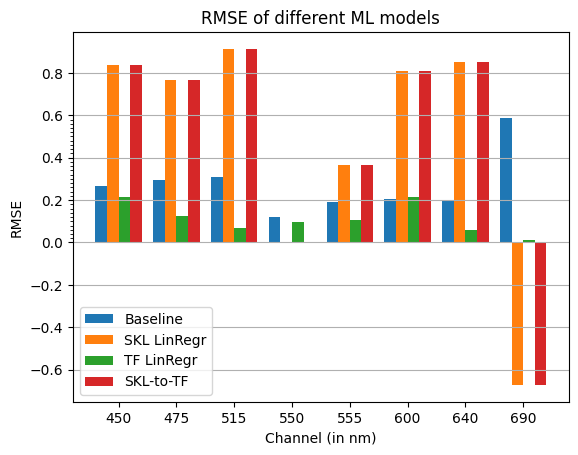

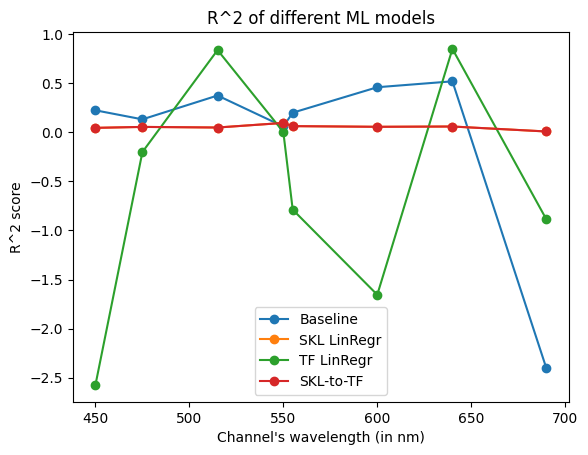

In [ ]:
plotRMSE(RMSE_calib)

# RMSE_comparison['New Enclosure'] = RMSE_calib['XGBRegressor']
# plotRMSE(RMSE_comparison)

plotR2(r2_scores)

## plotting TF history

In [ ]:
for channel, hist in history_per_ch.items():
  plot_loss(history_per_ch[channel])

NameError: name 'history_per_ch' is not defined

## Plotting Regression

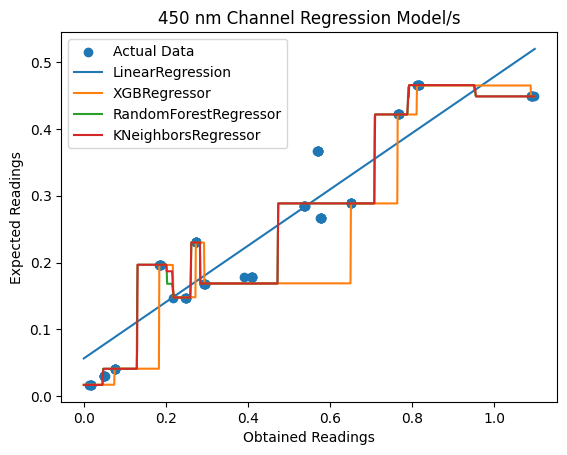

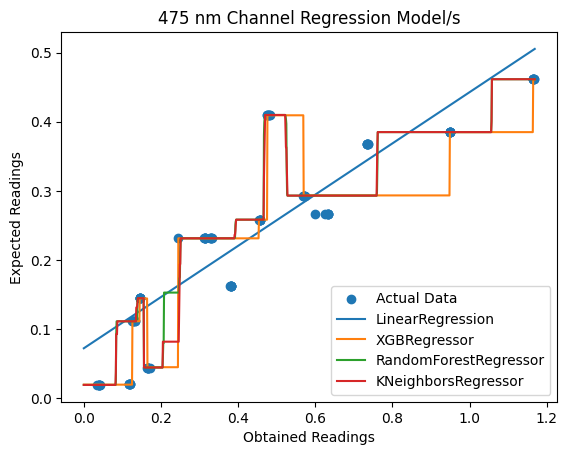

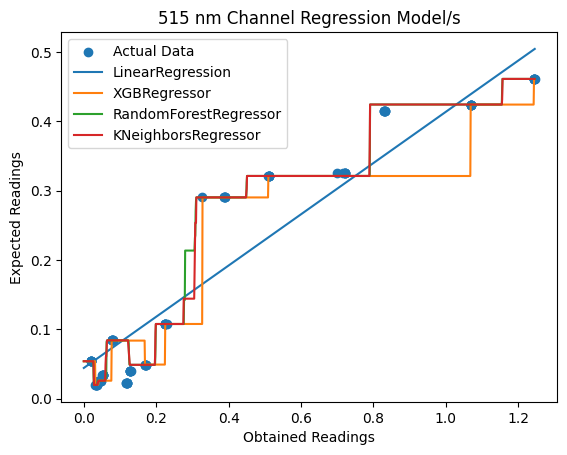

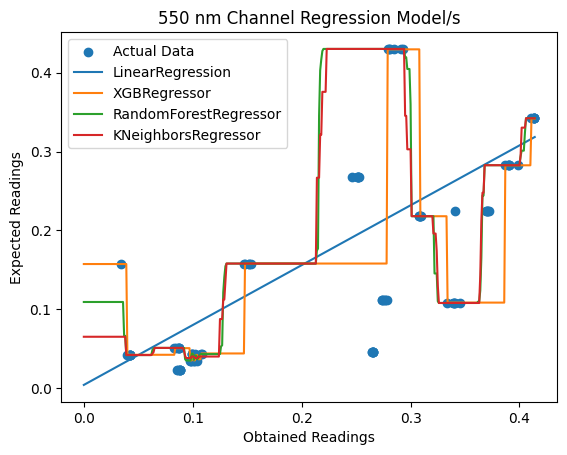

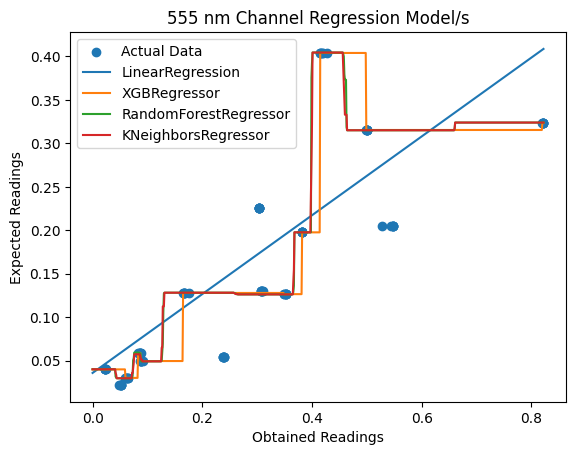

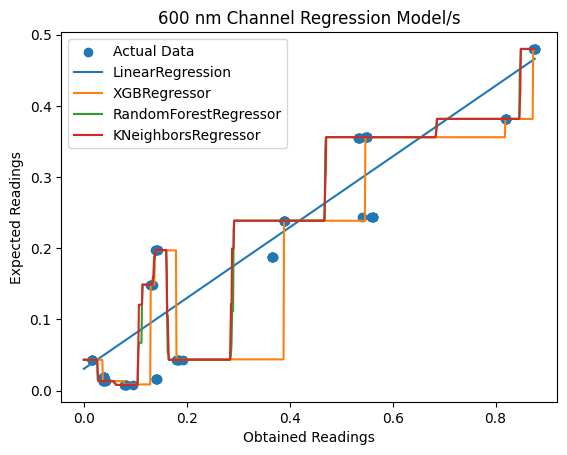

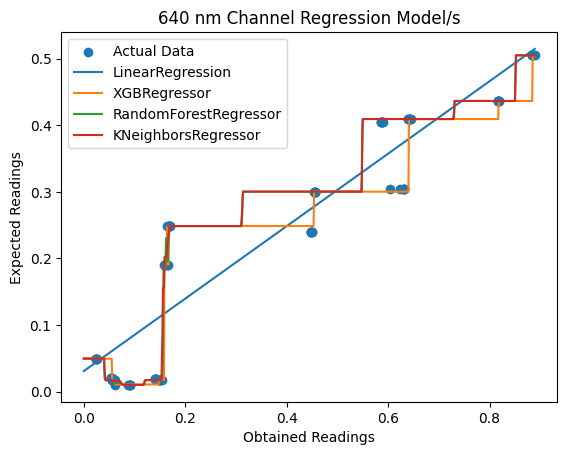

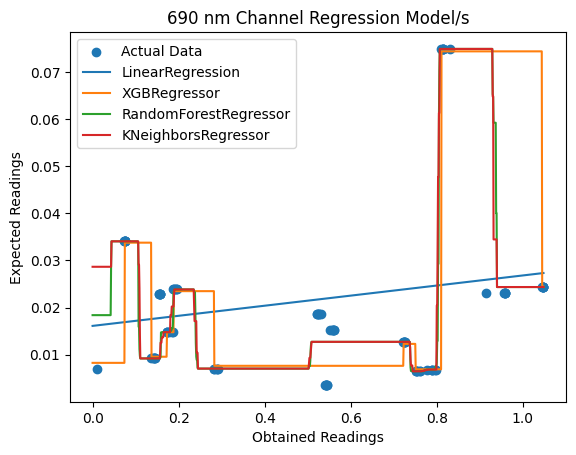

In [ ]:
# loop over all channels

for channel in ch: # channel is str type
    df = loadFile(f'ch{channel}.csv')
    x, y = df.iloc[:,2].to_numpy().reshape(-1, 1), df.iloc[:,1].to_numpy()
    # print(f'x max = {x.max()}')
    # print(f'y max = {y.max()}')
    # xgb = xgb_models[f'{channel} nm']
    # lin = lin_models[f'{channel} nm']
    # tflow = tf_models[f'{channel} nm']
    # skl_to_tf = skl_to_tf_models[f'{channel} nm']

    lin = calib_models['LinearRegression'][ch.index(channel)]
    xgb = calib_models['XGBRegressor'][ch.index(channel)]
    rfr = calib_models['RandomForestRegressor'][ch.index(channel)]
    knr = calib_models['KNeighborsRegressor'][ch.index(channel)]

    plotRegression(channel, [lin, xgb, rfr, knr], x, y)

## Plotting Calibrated Spectrum

In [ ]:
colors = ['r', 'y', 'g', 'b', '#7F00FF']
color_name = {
    'r': 'Red',
    'y': 'Yellow',
    'g': 'Green',
    'b': 'Blue',
    '#7F00FF': 'Violet'
}
ch = [450, 475, 515, 550, 555, 600, 640, 690]
df_ch = [] # store data here

offset = 2 # get 3rd sample from each set

# get all data
for channel in ch:
  df_raw = loadFile(f'ch{str(channel)}.csv')
  x, y = df_raw.iloc[:,2].to_numpy().reshape(-1, 1), df_raw.iloc[:,1].to_numpy()
  df_ch.append([x, y])

calib_spectrum =   {}
uncalib_spectrum = {}
target_spectrum =  {}

for color in colors:
  color_offset = colors.index(color)

  calib_spectrum[color] =   [[], [], []]
  uncalib_spectrum[color] = [[], [], []]
  target_spectrum[color] =  [[], [], []]

  for channel in ch:
    ch_idx = ch.index(channel)

    target_spectrum[color][0].append(df_ch[ch_idx][0][(color_offset*18)+offset+(6*0)]) #lightest shade
    target_spectrum[color][1].append(df_ch[ch_idx][0][(color_offset*18)+offset+(6*1)]) #medium shade
    target_spectrum[color][2].append(df_ch[ch_idx][0][(color_offset*18)+offset+(6*2)]) #darkest shade

    uncalib_spectrum[color][0].append(df_ch[ch_idx][1][(color_offset*18)+offset+(6*0)]) #lightest shade
    uncalib_spectrum[color][1].append(df_ch[ch_idx][1][(color_offset*18)+offset+(6*1)]) #medium shade
    uncalib_spectrum[color][2].append(df_ch[ch_idx][1][(color_offset*18)+offset+(6*2)]) #darkest shade
  ##### end of for-loop

  calib_spectrum[color][0] = xgb_models[f'{str(channel)} nm'].predict(uncalib_spectrum[color][0]) #lightest shade
  calib_spectrum[color][1] = xgb_models[f'{str(channel)} nm'].predict(uncalib_spectrum[color][1]) #medium shade
  calib_spectrum[color][2] = xgb_models[f'{str(channel)} nm'].predict(uncalib_spectrum[color][2]) #darkest shade

  print(ch)
  print(list(calib_spectrum[color][0]))
  # plot the spectrum for this color
  # plt.plot(ch, uncalib_spectrum[color][0], label="AS7343 lightest",color=color,)
  # plt.plot(ch, uncalib_spectrum[color][1], label="AS7343 medium",color=color)
  # plt.plot(ch, uncalib_spectrum[color][2], label="AS7343 lightest",color=color)
  plt.plot(ch, calib_spectrum[color][0], label="MSI lightest",linestyle='--',color=color)
  plt.plot(ch, calib_spectrum[color][1], label="MSI medium",linestyle='--',color=color)
  plt.plot(ch, calib_spectrum[color][2], label="MSI lightest",linestyle='--',color=color)
  plt.legend()
  plt.ylabel("Absorbance")
  plt.xlabel("wavelength in nm")
  plt.title(f"{color_name[color]} Sample Absorbance Spectrum")
  plt.show()


## Visualizing models

In [ ]:
# node_params = { "shape" : "box",
#                 "style" : "filled, rounded",
#                 "fillcolor" : "#78cbe" }
# leaf_params = { "shape" : "box",
#                 "style" : "filled",
#                 "fillcolor" : "#e48038" }

# tree0 = xgb.to_graphviz(model, tree_idx=0, size="10,10",
#                 condition_node_params=node_params,
#                 leaf_node_params=leaf_params)



# tree1 = xgb.to_graphviz(model, tree_idx=1, size="10,10",
#                 condition_node_params=node_params,
#                 leaf_node_params=leaf_params)
# tree1

# Color Classification

## Obtaining Reference Spectrum

In [ ]:
ch = ["450", "475", "515", "550", "555", "600", "640", "690"]
color_names = ['red', 'ylw', 'grn', 'blu','vio']
df_per_color = {}

for color in color_names:
    df_per_color[color] = np.array([
         [],[],[],[],[],[],
         [],[],[],[],[],[],
         [],[],[],[],[],[]])
    label = np.array([[color]*18]).reshape(-1,1)
    df_per_color[color] = np.concatenate((df_per_color[color], label), axis=1)

for channel in ch: # channel is str type
    df = loadFile(f'ch{channel}.csv')
    x, y = df.iloc[:,2].to_numpy().reshape(-1, 1), df.iloc[:,1].to_numpy()
    y_pred = np.array(xgb_models[f'{channel} nm'].predict(x)).reshape(-1,1)
    # print(f'Shape: {y_pred.shape}')
    # rmse = round(np.sqrt(mse(y, y_pred)), 5)
    # print(f'{channel}nm: {rmse}')

    for color in color_names:
        idx = color_names.index(color)
        start, end = idx*18, (idx+1)*18
        df_per_color[color] = np.concatenate((df_per_color[color], y_pred[start:end]), axis=1)

# compile into single array
full_data = np.array([['color', '450nm', '475nm', '515nm', '550nm', '555nm', '600nm', '640nm', '690nm']])
for color in color_names:
    full_data = np.concatenate((full_data, df_per_color[color]))

# CONVERT TO PANDAS DATAFRAME
df_ref = pd.DataFrame(data=full_data[1:,:], columns=full_data[0,:])

df_ref['450nm'] = pd.to_numeric(df_ref['450nm'])
df_ref['475nm'] = pd.to_numeric(df_ref['475nm'])
df_ref['515nm'] = pd.to_numeric(df_ref['515nm'])
df_ref['550nm'] = pd.to_numeric(df_ref['550nm'])
df_ref['555nm'] = pd.to_numeric(df_ref['555nm'])
df_ref['600nm'] = pd.to_numeric(df_ref['600nm'])
df_ref['640nm'] = pd.to_numeric(df_ref['640nm'])
df_ref['690nm'] = pd.to_numeric(df_ref['690nm'])

df_ref.head()

## Obtaining Calibrated Values

Please run ONLY ONE of the cells below.

### XGB Regressor

In [ ]:
ch = ["450", "475", "515", "550", "555", "600", "640", "690"]
color_names = ['red', 'ylw', 'grn', 'blu','vio']
df_per_color = {}

for color in color_names:
    df_per_color[color] = np.array([
         [],[],[],[],[],[],
         [],[],[],[],[],[],
         [],[],[],[],[],[]])
    label = np.array([[color]*18]).reshape(-1,1)
    df_per_color[color] = np.concatenate((df_per_color[color], label), axis=1)

for channel in ch: # channel is str type
    df = loadFile(f'ch{channel}.csv')
    x, y = df.iloc[:,2].to_numpy().reshape(-1, 1), df.iloc[:,1].to_numpy()
    y_pred = np.array(xgb_models[f'{channel} nm'].predict(x)).reshape(-1,1)
    # print(f'Shape: {y_pred.shape}')
    # rmse = round(np.sqrt(mse(y, y_pred)), 5)
    # print(f'{channel}nm: {rmse}')

    for color in color_names:
        idx = color_names.index(color)
        start, end = idx*18, (idx+1)*18
        df_per_color[color] = np.concatenate((df_per_color[color], y_pred[start:end]), axis=1)

# compile into single array
full_data = np.array([['color', '450nm', '475nm', '515nm', '550nm', '555nm', '600nm', '640nm', '690nm']])
for color in color_names:
    full_data = np.concatenate((full_data, df_per_color[color]))

# CONVERT TO PANDAS DATAFRAME
df = pd.DataFrame(data=full_data[1:,:], columns=full_data[0,:])
df.head()

df['450nm'] = pd.to_numeric(df['450nm'])
df['475nm'] = pd.to_numeric(df['475nm'])
df['515nm'] = pd.to_numeric(df['515nm'])
df['550nm'] = pd.to_numeric(df['550nm'])
df['555nm'] = pd.to_numeric(df['555nm'])
df['600nm'] = pd.to_numeric(df['600nm'])
df['640nm'] = pd.to_numeric(df['640nm'])
df['690nm'] = pd.to_numeric(df['690nm'])

df['color'] = pd.Categorical(df['color']).codes

### Linear Regression

In [ ]:
ch = ["450", "475", "515", "550", "555", "600", "640", "690"]
color_names = ['red', 'ylw', 'grn', 'blu','vio']
df_per_color = {}

for color in color_names:
    df_per_color[color] = np.array([
         [],[],[],[],[],[],
         [],[],[],[],[],[],
         [],[],[],[],[],[]])
    label = np.array([[color]*18]).reshape(-1,1)
    df_per_color[color] = np.concatenate((df_per_color[color], label), axis=1)

for channel in ch: # channel is str type
    df = loadFile(f'ch{channel}.csv')
    x, y = df.iloc[:,2].to_numpy().reshape(-1, 1), df.iloc[:,1].to_numpy()
    y_pred = np.array(lin_models[f'{channel} nm'].predict(x)).reshape(-1,1)
    # print(f'Shape: {y_pred.shape}')
    # rmse = round(np.sqrt(mse(y, y_pred)), 5)
    # print(f'{channel}nm: {rmse}')

    for color in color_names:
        idx = color_names.index(color)
        start, end = idx*18, (idx+1)*18
        df_per_color[color] = np.concatenate((df_per_color[color], y_pred[start:end]), axis=1)

# compile into single array
full_data = np.array([['color', '450nm', '475nm', '515nm', '550nm', '555nm', '600nm', '640nm', '690nm']])
for color in color_names:
    full_data = np.concatenate((full_data, df_per_color[color]))

# CONVERT TO PANDAS DATAFRAME
df = pd.DataFrame(data=full_data[1:,:], columns=full_data[0,:])
df.head()

df['450nm'] = pd.to_numeric(df['450nm'])
df['475nm'] = pd.to_numeric(df['475nm'])
df['515nm'] = pd.to_numeric(df['515nm'])
df['550nm'] = pd.to_numeric(df['550nm'])
df['555nm'] = pd.to_numeric(df['555nm'])
df['600nm'] = pd.to_numeric(df['600nm'])
df['640nm'] = pd.to_numeric(df['640nm'])
df['690nm'] = pd.to_numeric(df['690nm'])

## Prepare Data

### Calibrated train&test

In [ ]:
df['color'] = pd.Categorical(df['color']).codes

X = df.drop('color', axis=1).copy()
y = pd.Categorical(df['color']).codes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3333, random_state=42, stratify=y)

### MSI train, Calibrated test

In [ ]:
df_ref['color'] = pd.Categorical(df_ref['color']).codes

X_train = df_ref.drop('color', axis=1).copy()
y_train = pd.Categorical(df_ref['color']).codes

df['color'] = pd.Categorical(df['color']).codes

X_test = df.drop('color', axis=1).copy()
y_test = pd.Categorical(df['color']).codes

## Training Classification Model

In [ ]:
classifier_models = {}

xgboost = xgb.XGBClassifier(objective='binary:logistic', seed=42,
    early_stopping_rounds=10,
    eval_metric='auc',)

xgboost.fit(
    X_train,
    y_train,
    eval_set=[(X_test,y_test)],
    verbose=True,)

## Model Performance

In [ ]:
# plot_confusion_matrix(xgboost, X_test, y_test,values_format='d', display_labels=['Green', 'Violet', 'Yellow', 'Red', 'Blue'])

print(xgboost.classes_)
y_pred = xgboost.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=[xgboost.classes_])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Blue', 'Green', 'Red', 'Violet', 'Yellow'])
disp.plot()
plt.show()

# Concentration Regression

## Generate Labels

In [ ]:
# create the labels

mL_per_drop = 0.05 # set this to how many mL are in a drop

conv = mL_per_drop/0.05
labels = np.array([[]])

label_0125 = np.array([[0.125*conv]*6])
label_025  = np.array([[0.25*conv]*6])
label_030  = np.array([[0.30*conv]*6])
label_0375 = np.array([[0.375*conv]*6])
label_045  = np.array([[0.45*conv]*6])
label_0625 = np.array([[0.625*conv]*6])
label_075  = np.array([[0.75*conv]*6])
label_125  = np.array([[1.25*conv]*6])
label_175  = np.array([[1.75*conv]*6])


# red
labels = np.concatenate((labels, label_025), axis=1)
labels = np.concatenate((labels, label_075), axis=1)
labels = np.concatenate((labels, label_175), axis=1)
# yellow
labels = np.concatenate((labels, label_025), axis=1)
labels = np.concatenate((labels, label_0625), axis=1)
labels = np.concatenate((labels, label_175), axis=1)
# green
labels = np.concatenate((labels, label_025), axis=1)
labels = np.concatenate((labels, label_075), axis=1)
labels = np.concatenate((labels, label_125), axis=1)
# blue
labels = np.concatenate((labels, label_0125), axis=1)
labels = np.concatenate((labels, label_0375), axis=1)
labels = np.concatenate((labels, label_075), axis=1)
# violet
labels = np.concatenate((labels, label_030), axis=1)
labels = np.concatenate((labels, label_045), axis=1)
labels = np.concatenate((labels, label_075), axis=1)



In [ ]:
labels = labels.reshape(-1,1)
df_concentrations = pd.DataFrame(data=labels, columns=['Concentration'])
df_concentrations.head()

print(f'labels.shape = {labels.shape}')
# df_ref = pd.concat([df_ref, df_concentrations], axis=1)
# df_ref.head()

df_concentrations.head()

## Prepare Data

### Calibrated train&test

### MSI train, Calibrated test

In [ ]:
# including color labels (one-hot encoding)
X_train = pd.get_dummies(df_ref, columns=['color'])
y_train = df_concentrations.copy()

X_test = pd.get_dummies(df, columns=['color'])
y_test = df_concentrations.copy()

# excluding color labels
# X_train = df_ref.drop('color', axis=1).copy()
# y_train = df_concentrations.copy()

# X_test = df.drop('color', axis=1).copy()
# y_test = df_concentrations.copy()

data = {
    'X_train':  X_train,
    'y_train':  y_train,
    'X_test':   X_test,
    'y_test':   y_test,
}

print('Data Sizes')
for key, val in data.items():
  print(f'{key}\t: {val.shape}')

# data['X_train'].head()
# data['y_train'].head()
# data['X_test'].head()
# data['y_test'].head()

# pd.get_dummies(df, columns=['color']).head()

## Training Regression Models

### Initializing Variables

In [ ]:
# models to be trained
models = [xgb.XGBRegressor(random_state=42),
          RandomForestRegressor(max_depth=3, max_features='sqrt', max_leaf_nodes=9, n_estimators=300, random_state=42),
          LinearRegression(),
          RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5),
          SVR(kernel='rbf', gamma=0.1, C=0.1, epsilon=0.01), data
          ]

# container for trained models
concentration_models = {}

RMSE = {}

r2_scores = {}

working_dir = "/content/drive/MyDrive/CoE 199 (2s2425)/AS7343 Calibration/abs_per_ch/"

### Training Models

In [ ]:
# iterate through all models
plotResults = True
for model in models:
  model.fit(data['X_train'], data['y_train'])
  y_pred = model.predict(data['X_test'])
  y_test = data['y_test']

  cn = model.__class__.__name__
  print('Performance Metrics:', cn)
  sr2 = round(r2_score(y_test, y_pred), 5)
  smae = round(mae(y_test, y_pred), 5)
  smse = round(np.sqrt(mse(y_test, y_pred)), 5)

  print('  metrics r2:', sr2)
  print('  mae:', smae)
  print('  rmse:', smse)
  print('')

  concentration_models[cn] = model
  RMSE[cn] = smse.item()
  r2_scores[cn] = sr2

## Model Performance

### Regression Plots

In [ ]:
for model in models:
    mdl_name = model.__class__.__name__
    tlbl = "Metrics"
    tr2 = f"$R^2$: {r2_scores[mdl_name]}"
    trmse = f"RMSE: {RMSE[mdl_name]}"

    rmse_per_color = []
    for i in range(0,5):
      X_test_color = data['X_test'][i*18:(i+1)*18]
      y_test_color = data['y_test'][i*18:(i+1)*18]
      y_pred_color = concentration_models[mdl_name].predict(X_test_color)
      rmse_per_color.append(round(np.sqrt(mse(y_test_color, y_pred_color)), 5).item())

    print(f'RMSE of {mdl_name} per color:\n{rmse_per_color}')

    # Add the text to the plot
    plt.text(0.05, 0.95, tlbl, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
    plt.text(0.05, 0.88, tr2, transform=plt.gca().transAxes, fontsize=8, verticalalignment='top')
    plt.text(0.05, 0.82, trmse, transform=plt.gca().transAxes, fontsize=8, verticalalignment='top')

    step_size = 0.001
    x = np.arange(0,1.75+step_size, step_size)
    plt.plot(x, x, label="1:1 line")

    # y_pred = concentration_models[mdl_name].predict(data['X_test'])
    # plt.scatter(y_pred, data['y_test'], label="Test Data")
    # y_pred = concentration_models[mdl_name].predict(data['X_train'])
    # plt.scatter(y_pred, data['y_train'], label="Train Data")

    y_pred = concentration_models[mdl_name].predict(data['X_test'][0:17])
    plt.scatter(y_pred, data['y_test'][0:17], label="Red samples", color='r')
    y_pred = concentration_models[mdl_name].predict(data['X_test'][18:35])
    plt.scatter(y_pred, data['y_test'][18:35], label="Yellow samples", color='y')
    y_pred = concentration_models[mdl_name].predict(data['X_test'][36:53])
    plt.scatter(y_pred, data['y_test'][36:53], label="Green samples", color='g')
    y_pred = concentration_models[mdl_name].predict(data['X_test'][54:71])
    plt.scatter(y_pred, data['y_test'][54:71], label="Blue samples", color='b')
    y_pred = concentration_models[mdl_name].predict(data['X_test'][72:89])
    plt.scatter(y_pred, data['y_test'][72:89], label="Violet samples", color='#7F00FF')

    plt.legend()
    plt.xlabel("Predicted concentration (% volume)")
    plt.ylabel("Actual concentration (% volume)")
    plt.title(f"{mdl_name} Scatter Plot")
    plt.show()

### RMSE Scores

In [ ]:
for key, val in RMSE.items():
  print(f'{key}\t: {val}')

# Concentration Regression V2

## Extract Data

In [ ]:
workingDir = "/content/drive/MyDrive/CoE 199 (2s2425)/AS7343 Calibration/raw_to_abs/"
csvPath = workingDir + "raw_concentrations.csv"
raw_df = pd.read_csv(csvPath)

# separate into colors
raw_df_red = raw_df.iloc[ 0: 8, 0:33].copy()
raw_df_blu = raw_df.iloc[ 9:17, 0:24].copy()
raw_df_ylw = raw_df.iloc[18:26,  :  ].copy()

red_baseline = pd.DataFrame(data=raw_df_red.pop('baseline'), columns=['baseline'], dtype='int64')
blu_baseline = pd.DataFrame(data=raw_df_blu.pop('baseline'), columns=['baseline'], dtype='int64')
ylw_baseline = pd.DataFrame(data=raw_df_ylw.pop('baseline'), columns=['baseline'], dtype='int64')

# wavelength column
abs_df_red = pd.DataFrame(data=np.array(raw_df_red['red']), columns=['WaveLength'])
abs_df_blu = pd.DataFrame(data=np.array(raw_df_blu['red']), columns=['WaveLength'])
abs_df_ylw = pd.DataFrame(data=np.array(raw_df_ylw['red']), columns=['WaveLength'])

abs_baseline = pd.DataFrame(data=[[0],[0],[0],[0],[0],[0],[0],[0]], columns=['0'])

# add baseline plot (0 absorbance)
abs_df_red = pd.concat([abs_df_red, abs_baseline], axis=1)
abs_df_blu = pd.concat([abs_df_blu, abs_baseline], axis=1)
abs_df_ylw = pd.concat([abs_df_ylw, abs_baseline], axis=1)

# red
for col in range(1, 32):
  abs_list = [math.log( red_baseline.iloc[i].item() / raw_df_red.iloc[i,col].item() ) for i in range(0,8)]
  abs = pd.DataFrame(data=abs_list, columns=[raw_df_red.columns[col]], dtype='float64')
  abs_df_red = pd.concat([abs_df_red, abs], axis=1)

# blue
for col in range(1, 23):
  abs_list = [math.log( blu_baseline.iloc[i].item() / raw_df_blu.iloc[i,col].item() ) for i in range(0,8)]
  abs = pd.DataFrame(data=abs_list, columns=[raw_df_blu.columns[col]], dtype='float64')
  abs_df_blu = pd.concat([abs_df_blu, abs], axis=1)

# yellow
for col in range(1, 35):
  abs_list = [math.log( ylw_baseline.iloc[i].item() / raw_df_ylw.iloc[i,col].item() ) for i in range(0,8)]
  abs = pd.DataFrame(data=abs_list, columns=[raw_df_ylw.columns[col]], dtype='float64')
  abs_df_ylw = pd.concat([abs_df_ylw, abs], axis=1)

# np arrays of the absorbances
abs_np_red = np.array(abs_df_red)
abs_np_blu = np.array(abs_df_blu)
abs_np_ylw = np.array(abs_df_ylw)

print(abs_np_red.shape)
print(abs_np_blu.shape)
print(abs_np_ylw.shape)

# np array of # of drops
drops = np.array(abs_df_ylw.columns[1:-1]).astype('int')

# % saturation = 1 + log( drops / max_drops )*100
# saturation = np.array([ 100*(math.log(drops[i]+1)/math.log(drops.max()+1)) for i in range(len(drops)) ])

saturation_ls = []
for drop in drops:
  saturation_ls.append([100*(math.log(drop+1)/math.log(drops.max()+1))])
saturation = np.array(saturation_ls)
print(saturation.shape)
print(drops)


## Plot Uncalibrated Spectrum

In [ ]:
# reds
i_max = abs_np_red.shape[1]
for i in range(1, i_max):
  plt.plot(abs_np_red[:,0], abs_np_red[:,i],
           label=f'{drops[i]} drops',
           color=(1-i*(0.6/i_max), 0.78-i*(0.78/i_max), 0.78-i*(0.78/i_max)))
plt.xlabel("Wavelength (in nm)")
plt.ylabel("Absorbance")
plt.title(f"Absorbance spectrum of red samples with increasing saturation")
# plt.legend()
plt.show()

# blues
i_max = abs_np_blu.shape[1]
for i in range(1, abs_np_blu.shape[1]):
  plt.plot(abs_np_blu[:,0], abs_np_blu[:,i],
           label=f'{drops[i]} drops',
           color=(0.85-i*(0.85/i_max), 0.92-i*(0.59/i_max), 1-i*(0.5/i_max)))
plt.xlabel("Wavelength (in nm)")
plt.ylabel("Absorbance")
plt.title(f"Absorbance spectrum of blue samples with increasing saturation")
# plt.legend()
plt.show()

# yellow
i_max = abs_np_ylw.shape[1]
for i in range(1, abs_np_ylw.shape[1]-1):
  plt.plot(abs_np_ylw[:,0], abs_np_ylw[:,i],
           label=f'{drops[i]} drops',
           color=(1-i*(0.3/i_max), 1-i*(0.4/i_max), 0.7-i*(0.7/i_max)))
plt.xlabel("Wavelength (in nm)")
plt.ylabel("Absorbance")
plt.title(f"Absorbance spectrum of yellow samples with increasing saturation")
# plt.legend()
plt.show()

## Scatterplot

In [ ]:
# what do you want to plot?
vs_no_of_drops = False
vs_saturation  = True

# vs no. of drops (log scale)
if (vs_no_of_drops):
  for i in range(8):
    i_max = abs_np_red.shape[1]-1
    plt.scatter(drops[:i_max], abs_np_red[i,1:], label='Red samples', color='red')

    i_max = abs_np_blu.shape[1]-1
    plt.scatter(drops[:i_max], abs_np_blu[i,1:], label='Blue samples', color='blue')

    i_max = abs_np_ylw.shape[1]-1
    plt.scatter(drops[:i_max], abs_np_ylw[i,1:], label='Yellow samples', color=(1,0.9,0.3))

    plt.xscale('log')
    plt.xlabel("No. of drops")
    plt.ylabel("Absorbance")
    plt.title(f"Absorbance of all samples at {int(abs_np_red[i,0])}nm vs no. of drops")
    plt.legend()
    plt.show()

# vs saturation (lin scale)
if (vs_saturation):
  for i in range(8):
    i_max = abs_np_red.shape[1]-1
    plt.scatter(saturation[:i_max], abs_np_red[i,1:], label='Red samples', color='red')

    i_max = abs_np_blu.shape[1]-1
    plt.scatter(saturation[:i_max], abs_np_blu[i,1:], label='Blue samples', color='blue')

    i_max = abs_np_ylw.shape[1]-1
    print(abs_np_ylw[i,1:-1].shape)
    print(saturation[:i_max].shape)
    plt.scatter(saturation[:i_max], abs_np_ylw[i,1:-1], label='Yellow samples', color=(1,0.9,0.3))

    plt.xlabel("% Saturation")
    plt.ylabel("Absorbance")
    plt.title(f"Absorbance of all samples at {int(abs_np_red[i,0])}nm vs no. of drops")
    plt.legend()
    plt.show()


## Prepare Data for Training

In [ ]:
# add color labels
label_red = pd.DataFrame(data=np.array(['red']*33).reshape(1,-1))
label_blu = pd.DataFrame(data=np.array(['blue']*24).reshape(1,-1))
label_ylw = pd.DataFrame(data=np.array(['yellow']*36).reshape(1,-1))

abs_np_red = np.concat([abs_df_red, label_red], axis=0)
abs_np_blu = np.concat([abs_df_blu, label_blu], axis=0)
abs_np_ylw = np.concat([abs_df_ylw, label_ylw], axis=0)

# print(abs_np_ylw.shape)

data_red = abs_np_red.transpose()
data_red[0,8] = 'color'
columns = data_red[0,:]
# print(columns)
data_red = np.delete(data_red, (0), axis=0)
data_blu = abs_np_blu.transpose()
data_blu = np.delete(data_blu, (0), axis=0)
data_ylw = abs_np_ylw.transpose()
data_ylw = np.delete(data_ylw, (0), axis=0)



# concatenate into single np.array
data_ALL = np.concat([data_red, data_blu, data_ylw], axis=0)
print(data_ALL.shape)
# prepare total saturation column
saturation_ALL = np.concat([saturation[:32], saturation[:23], saturation[:38], [[100]]], axis=0)
print(saturation_ALL.shape)
# transform into dataframes
data_ALL_df = pd.DataFrame(data=data_ALL, columns=columns)
data_ALL_df[['450', '475', '515', '550', '555', '600', '640', '690']] = data_ALL_df[['450', '475', '515', '550', '555', '600', '640', '690']].apply(pd.to_numeric)
print(data_ALL_df.shape)

saturation_ALL_df = pd.DataFrame(data=saturation_ALL, columns=['saturation']).astype('float')
# print(saturation_ALL_df)

print(data_ALL_df.iloc[:3,:])
print(saturation_ALL_df.iloc[:3,:])
print(data_ALL_df.iloc[31:34,:])
print(saturation_ALL_df.iloc[31:34,:])
print(data_ALL_df.iloc[54:58,:])
print(saturation_ALL_df.iloc[54:58,:])
print(data_ALL_df.iloc[87:,:])
print(saturation_ALL_df.iloc[87:,:])

Getting Train-Test Split now

In [ ]:
X_all = pd.get_dummies(data_ALL_df, columns=['color'])
y_all = saturation_ALL_df.copy()

print(f'{X_all.shape}')
print(f'{y_all.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=data_ALL_df['color'])

all_test = pd.concat([X_test, y_test], axis=1)
all_test_red = all_test[all_test['color_red'] == True]
all_test_blu = all_test[all_test['color_blue'] == True]
all_test_ylw = all_test[all_test['color_yellow'] == True]
print(all_test_blu)

X_test_red = all_test_red.drop(['saturation'], axis=1).copy()
y_test_red = all_test_red['saturation'].copy()
X_test_blu = all_test_blu.drop(['saturation'], axis=1).copy()
y_test_blu = all_test_blu['saturation'].copy()
X_test_ylw = all_test_ylw.drop(['saturation'], axis=1).copy()
y_test_ylw = all_test_ylw['saturation'].copy()

print(X_test_blu)
print(y_test_blu)

## Training Regression Models

### Initializing Variables

In [ ]:
# models to be trained
models = [xgb.XGBRegressor(random_state=42),
          RandomForestRegressor(max_depth=3, max_features='sqrt', max_leaf_nodes=9, n_estimators=300, random_state=42),
          LinearRegression(),
          RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5),
          SVR(kernel='rbf', gamma=0.1, C=0.1, epsilon=0.01)
          ]

# container for trained models
concentration_models = {}

RMSE = {}

RMSE_per_color = {}

r2_scores = {}

### Training Models

In [ ]:
# iterate through all models
plotResults = True
for model in models:
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  cn = model.__class__.__name__
  print('Performance Metrics:', cn)
  sr2 = round(r2_score(y_test, y_pred), 5)
  smae = round(mae(y_test, y_pred), 5)
  smse = round(np.sqrt(mse(y_test, y_pred)), 5)

  print('  metrics r2:', sr2)
  print('  mae:', smae)
  print('  rmse:', smse)
  print('')

  concentration_models[cn] = model
  RMSE[cn] = smse.item()
  r2_scores[cn] = sr2

  RMSE_per_color[cn] = []
  y_pred_red = concentration_models[cn].predict(X_test_red)
  y_pred_blu = concentration_models[cn].predict(X_test_blu)
  y_pred_ylw = concentration_models[cn].predict(X_test_ylw)

  rmse = round(np.sqrt(mse(y_test_red, y_pred_red)), 5)
  RMSE_per_color[cn].append(rmse.item())
  rmse = round(np.sqrt(mse(y_test_blu, y_pred_blu)), 5)
  RMSE_per_color[cn].append(rmse.item())
  rmse = round(np.sqrt(mse(y_test_ylw, y_pred_ylw)), 5)
  RMSE_per_color[cn].append(rmse.item())

  if (plotResults):
    # Add the text to the plot
    plt.text(0.05, 0.95, 'Performance Metrics', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
    plt.text(0.05, 0.88, f'R2: {r2_scores[cn]}', transform=plt.gca().transAxes, fontsize=8, verticalalignment='top')
    plt.text(0.05, 0.82, f'RMSE: {RMSE[cn]}', transform=plt.gca().transAxes, fontsize=8, verticalalignment='top')

    step_size = 0.01
    x = np.arange(0,100+step_size, step_size)
    plt.plot(x, x, label="1:1 line")

    plt.scatter(y_pred_red, y_test_red, label="Red samples", color='r')
    plt.scatter(y_pred_blu, y_test_blu, label="Blue samples", color='b')
    print(y_pred_ylw.shape)
    print(y_test_ylw.shape)
    plt.scatter(y_pred_ylw, y_test_ylw, label="Yellow samples", color='y')

    plt.legend()
    plt.xlabel("Predicted percent saturation")
    plt.ylabel("Actual percent saturation")
    plt.title(f"{cn} Scatter Plot")
    plt.show()


## Model Performance

In [ ]:
print('RMSE SCORES PER MODEL')
for key, val in RMSE.items():
  print(f'{key}\t: {val}')

print('RMSE SCORES PER MODEL PER COLOR')
for key, val in RMSE_per_color.items():
  print(f'{key}\t: {val}')

print('\nR^2 SCORES PER MODEL')
for key, val in r2_scores.items():
  print(f'{key}\t: {val}')



# New Calibration

## Extract Raw Data

In [ ]:
dir = "/content/drive/MyDrive/CoE 199 (2s2425)/AS7343 Calibration/"

raw_df = pd.read_csv(dir + "raw_outputs.csv")

# raw_df.dtypes

# build baseline spectrum without any corrections
abs_uncorr = pd.DataFrame([[]])
abs_uncorr = pd.concat([abs_uncorr, raw_df['channel'][0:8].copy()], axis=1)
# 0 //  1 2 3 4 // 5 6 7 8 // 9 10 11 12
cols = raw_df.columns
for color in range(0,3): # for every color
  for shade_num in range(0,3): # for every shade
    # get indices
    bl_idx = 1 + (color*4)
    sample_idx = 2 + (color*4) + shade_num
    # get spectrum
    baseline = np.array(raw_df[cols[bl_idx]][:8])
    sample = np.array(raw_df[cols[sample_idx]][:8])
    # calculate absorbance
    abs = []
    for x in range(8):
      abs.append(math.log(baseline[x] / sample[x]))
    abs_df = pd.DataFrame(np.array([abs]).reshape(-1,1), columns=[cols[sample_idx]])
    abs_uncorr = pd.concat([abs_uncorr, abs_df], axis=1)

print(abs_uncorr)



## Build Basic Output

In [ ]:
spectrum_basic = abs_uncorr['channel'].copy()

# 0 // 1 2 3 4 // 5 6 7 8 // 9 10 11 12
print(cols)
for color in range(3): # every color
  for shade in range(4): # every shade (including baseline)
    idx = 1 + (color*4) + shade
    col = cols[idx] # column name
    print(col)
    GAIN = raw_df[col][18]
    Tint = raw_df[col][19]
    spectrum = raw_df[col][10:18]
    basic = pd.DataFrame(raw_df[col][10:18] / (GAIN*Tint))
    basic = basic.set_index(pd.Index(range(8)))
    # basic = basic.shift(-10)
    # print(basic)
    spectrum_basic = pd.concat([spectrum_basic, basic], axis=1)

print(spectrum_basic)


## Get Basic Absorbance

In [ ]:
abs_basic = abs_uncorr['channel'].copy()

# 0 //  1 2 3 4 // 5 6 7 8 // 9 10 11 12

for color in range(0,3): # every color
  for shade in range(0,3): # every shade
    # get indices
    bl_idx = 1 + (color*4)
    sample_idx = 2 + (color*4) + shade
    # get spectrum
    baseline = np.array(spectrum_basic[cols[bl_idx]][:8])
    sample = np.array(spectrum_basic[cols[sample_idx]][:8])
    # calculate absorbance
    abs = []
    for x in range(8):
      abs.append(math.log(baseline[x] / sample[x]))
    abs_df = pd.DataFrame(np.array([abs]).reshape(-1,1), columns=[cols[sample_idx]])
    abs_basic = pd.concat([abs_basic, abs_df], axis=1)

print(abs_basic)
print(abs_uncorr)

## Plot Absorbances

In [ ]:
color_codes = {'red': 'red', 'yellow': 'orange', 'blue': 'blue'}
wavelengths = [450, 475, 515, 550, 555, 600, 640, 690]
print(list(color_codes.keys()))
cols = abs_basic.columns
# 0 // 1 2 3 // 4 5 6 // 7 8 9

# new absorbance spectrum using basic counts
for color in range(3):
  for shade in range(3):
    idx = 1 + (color*3) + shade
    color_name = list(color_codes.keys())[color]
    color_code = color_codes[color_name]
    name = cols[idx]
    plt.plot(wavelengths, abs_basic[name], color=color_code, marker='o')
  plt.title(f'New Absorbance of {color_name} samples')
  plt.xlabel('wavelengths (in nm)')
  plt.ylabel('absorbance')
  plt.show()

# old absorbance spectrum using non-corrected, raw counts
for color in range(3):
  for shade in range(3):
    idx = 1 + (color*3) + shade
    color_name = list(color_codes.keys())[color]
    color_code = color_codes[color_name]
    name = cols[idx]
    plt.plot(wavelengths, abs_basic[name], color=color_code, marker='o')
  plt.title(f'Old Absorbance of {color_name} samples')
  plt.xlabel('wavelengths (in nm)')
  plt.ylabel('absorbance')
  plt.show()